## Goal:
Transform my Control System Revision system to use a 2-stage chain-of-thought (CoT) approach, present the output in a clean, magazine-like format.

Original Goal:   
A knowledgeable and patient tutor + revision partner for Control Systems that assesses and strengthens understanding of key concepts.

## CoT workflow
**1st phase(thinking)** :   
Let LLM identifies the ideal structure for a good response (e.g., using examples for clarity),   
then generates 3 possible responses to the question.   
**2nd phase (reply)** : consider the pros and cons of each responses,   
summarizing the pros and follow the summary to generating reply.   

## Planning : divide and conquer --> implement

In [ ]:
import os
from google.colab import userdata

In [ ]:
# Groq
api_key = userdata.get('Groq')
os.environ['GROQ_API_KEY']=api_key
provider = "groq"

model_llama3 = "llama3-70b-8192"

model_llama3_versatile = "llama-3.3-70b-versatile"


In [ ]:
!pip install aisuite[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.9/863.9 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.5/103.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 42.7 MB/s eta 0:00:00
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.10.0 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.27.2 which is incompatible.


In [ ]:
import aisuite as ai

In [ ]:
provider_planner = "groq"
model_planner = model_llama3_versatile

provider_writer = "groq"
model_writer = model_llama3

#provider_reviewer = ""
#model_reviewer = ""

# Original version

In [ ]:
def reply(system='''
You are a knowledgeable and patient tutor +
revision partner specializing in Control Systems.
Your goal is to assess and enhance the user’s understanding of key concepts.''',
          prompt="Please reply in a clear and structural way",
          provider="groq",
          model="llama3-70b-8192"
          ):

    client = ai.Client()

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": prompt}
    ]


    response = client.chat.completions.create(model=f"{provider}:{model}", messages=messages)

    return response.choices[0].message.content

In [ ]:
reply()

"I'd be happy to help.\n\nTo ensure a clear and structured response, I'll follow this format:\n\n**Topic**: [The specific concept or topic we're discussing]\n**Explanation**: [A clear and concise explanation of the concept]\n**Example**: [A relevant example to illustrate the concept]\n**Question**: [A question to check your understanding or encourage further thought]\n**Your Turn**: [An opportunity for you to ask questions, share your thoughts, or request clarification]\n\nLet's get started! What aspect of Control Systems would you like to explore?"

# Two Phase

In [ ]:
system_planner = '''You are a senior Control Systems engineer specializing in
identifying the core key points in a question.
Use bullet points to list these key points.
Then, determine an ideal structure for a good response based on these points
(e.g., using examples or analogies for clarity).
'''
system_writer = '''You are a science magazine chief editor who specializes in
selecting the best expert response and expanding on it.  '''

In [ ]:
from IPython.display import display, Markdown
def Revision(prompt):
    # Step 1
    planning_prompt = f'''User input{prompt}
    Based on the user's input and your chosen structure,please generate 3 possible responses to the question.
    At most 5 sentences in a response.
    Please separate each response into a distinct section,
    and leave a blank line between sections to improve readability.'''
    responses = reply(system_planner, planning_prompt,
                          provider = provider_planner,
                          model = model_planner
                          )

    # Step 2
    generation_prompt = f'''Here are my 3 versions regarding the topic :{responses}
    Please choose the most insightful and clear one.
    Do not repeat its content, just specify which number you pick (e.g., "I choose response 2").
    Then, list 3 reasons why you selected it over the other two.

    Next, elaborate on it using a friendly, logical style suitable for readers of all ages.
    Please keep these guidelines in mind.

    Plan your structure before start generating.
    Use a magazine-like format, clearly structured and easy to follow.
    Separate long sentences into paragraphs.
    Please only keep elaborate on the topic if necessary,if the ideas are already
    At most 5 sentences per paragraph.
    At most 3 paragraphs in total.
    Give each paragraph a concise title.
    Please ensure that each paragraph addresses a distinct key aspect of the topic.
    Don't state your instructions to the user.
    Play your role as a seasoned chief editor of a top-tier magazine.
    You know these editorial guidelines by heart.

    Separate each response into a distinct section and leave a blank line between sections for readability.

    Ensure that each paragraph addresses a distinct aspect of the topic.'''

    final_response = reply(system_writer, generation_prompt,
                       provider = provider_writer,
                       model = model_writer
                       )
    display(Markdown("### 🧠 Planning Responses\n" + responses))
    display(Markdown("### 📣 Final Magazine-Style Output\n" + final_response))

    return responses, final_response

# 中文版本

system_planner :  
你是一位資深的控制系統工程師，擅長從問題中抓出核心重點。

請先用條列方式整理使用者輸入中的主要概念或關鍵要點。  
接著，根據這些要點，規劃一個合適的回答架構。  
運用實際例子、比喻，並以清楚的邏輯來說明。  

使用者的提問如下：{prompt}.

根據這些內容與你設計的回答架構，請產出三個不同版本的回答建議。  
每則回答最多五句話。  
請將每則回答清楚分段，並在段落間保留空行，以利閱讀。  

system_ writer :   
你是一位專門撰寫科普雜誌的總編輯，  
擅長從多個專家回覆中選出最優秀的一則，並進一步加以延伸與潤飾。

以下是我針對這個主題的三個版本：{responses}.  
請挑出其中最清楚、最有深度的一個。
不要重複內容，只要直接指出你選的是第幾則（例如：「我選第二則」）。  
接著請列出三個你選它而非其他兩則的理由。  

然後，請用邏輯清楚、語氣親切的方式，進一步把這個觀點擴寫。適合各年齡層讀者閱讀。  
以下是寫作的編輯原則，請默默遵守，無需向讀者說明：  

先構思整體架構再開始寫作, 以雜誌文章的格式呈現，結構清楚

長句要斷成適當段落，讓閱讀更輕鬆。

僅在有需要時進一步說明，若原本觀點已完整，請避免過度延伸。

每段最多 5 句, 全文最多 3 段。

每段開頭請加上簡潔的標題, 且聚焦於主題的不同面向。

不需說明你是如何選擇與撰寫的，直接進入角色。  
你就是一位經驗老道的總編輯，這些原則你都已經銘記於心。

請將不同段落用清楚的區塊區隔，並在段落之間保留空行，讓整體排版更易讀。



In [ ]:
Revision("Why do we need feedback loop in control ?")

### 🧠 Planning Responses
## Response 1
The key points of the question are:
* Understanding the concept of a feedback loop
* Recognizing the importance of feedback in control systems
* Identifying the benefits of using feedback loops. 
A feedback loop is essential in control systems as it allows the system to adjust its output based on the actual outcome, ensuring stability and accuracy. This is crucial for maintaining optimal performance.

## Response 2
The core key points are:
* Definition of a feedback loop
* Purpose of using feedback in control systems
* Examples of feedback loop applications. 
A feedback loop is necessary to compare the system's output with the desired setpoint, making adjustments as needed to minimize errors. This is achieved through continuous monitoring and correction, which is vital for effective control.

## Response 3
The main points to consider are:
* Function of a feedback loop
* Importance of feedback in achieving desired outcomes
* Consequences of not using feedback loops. 
In control systems, a feedback loop plays a critical role in ensuring the system's output meets the desired specifications. Without a feedback loop, the system may not be able to correct deviations, leading to suboptimal performance and potential instability.

### 📣 Final Magazine-Style Output
I choose response 2.

Here are three reasons why I selected it:

1. Clear definition: Response 2 provides a concise and accurate definition of a feedback loop, making it easy for readers to understand the concept.
2. Focused explanation: The response effectively explains the purpose of using feedback in control systems, highlighting its importance in achieving optimal performance.
3. Concrete example: By mentioning the need for continuous monitoring and correction, Response 2 provides a tangible illustration of how feedback loops work in practice.

**The Crucial Role of Feedback Loops**

**Defining the Feedback Loop**

A feedback loop is a crucial component in control systems, allowing the system to compare its output with the desired setpoint. This comparison enables the system to make adjustments as needed, minimizing errors and ensuring optimal performance. By continuously monitoring and correcting its output, the system can adapt to changing circumstances and maintain stability.

**The Purpose of Feedback in Control Systems**

The primary purpose of a feedback loop is to ensure the system's output meets the desired specifications. Without feedback, the system would be unable to detect and correct deviations, leading to suboptimal performance and potential instability. By incorporating feedback loops, control systems can achieve precise control, accuracy, and reliability.

**Real-World Applications of Feedback Loops**

Feedback loops have numerous applications in various fields, including manufacturing, engineering, and biology. For instance, temperature control systems in industrial settings rely on feedback loops to maintain precise temperatures, ensuring efficient production and minimizing waste. Similarly, biological systems, such as the human body, use feedback loops to regulate vital functions like blood pressure and body temperature.

("## Response 1\nThe key points of the question are:\n* Understanding the concept of a feedback loop\n* Recognizing the importance of feedback in control systems\n* Identifying the benefits of using feedback loops. \nA feedback loop is essential in control systems as it allows the system to adjust its output based on the actual outcome, ensuring stability and accuracy. This is crucial for maintaining optimal performance.\n\n## Response 2\nThe core key points are:\n* Definition of a feedback loop\n* Purpose of using feedback in control systems\n* Examples of feedback loop applications. \nA feedback loop is necessary to compare the system's output with the desired setpoint, making adjustments as needed to minimize errors. This is achieved through continuous monitoring and correction, which is vital for effective control.\n\n## Response 3\nThe main points to consider are:\n* Function of a feedback loop\n* Importance of feedback in achieving desired outcomes\n* Consequences of not using fe

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

In [ ]:
with gr.Blocks() as demo:
    gr.Markdown("## 🕹️ Control System Revision Partner")
    gr.Markdown("Enter a question you're curious about and get a beautifully written, educational response!")

    user_input = gr.Textbox(label="💡 My curiosity:")
    btn = gr.Button("✨ Get a magazine-style response!")

    with gr.Row():
        out1 = gr.Textbox(label="🧠 Planning", lines=10)
        out2 = gr.Textbox(label="📣 Final Magazine Post", lines=10)

    btn.click(Revision, inputs=[user_input], outputs=[out1, out2])

In [ ]:
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1143017ccbd6d00fcf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Some results

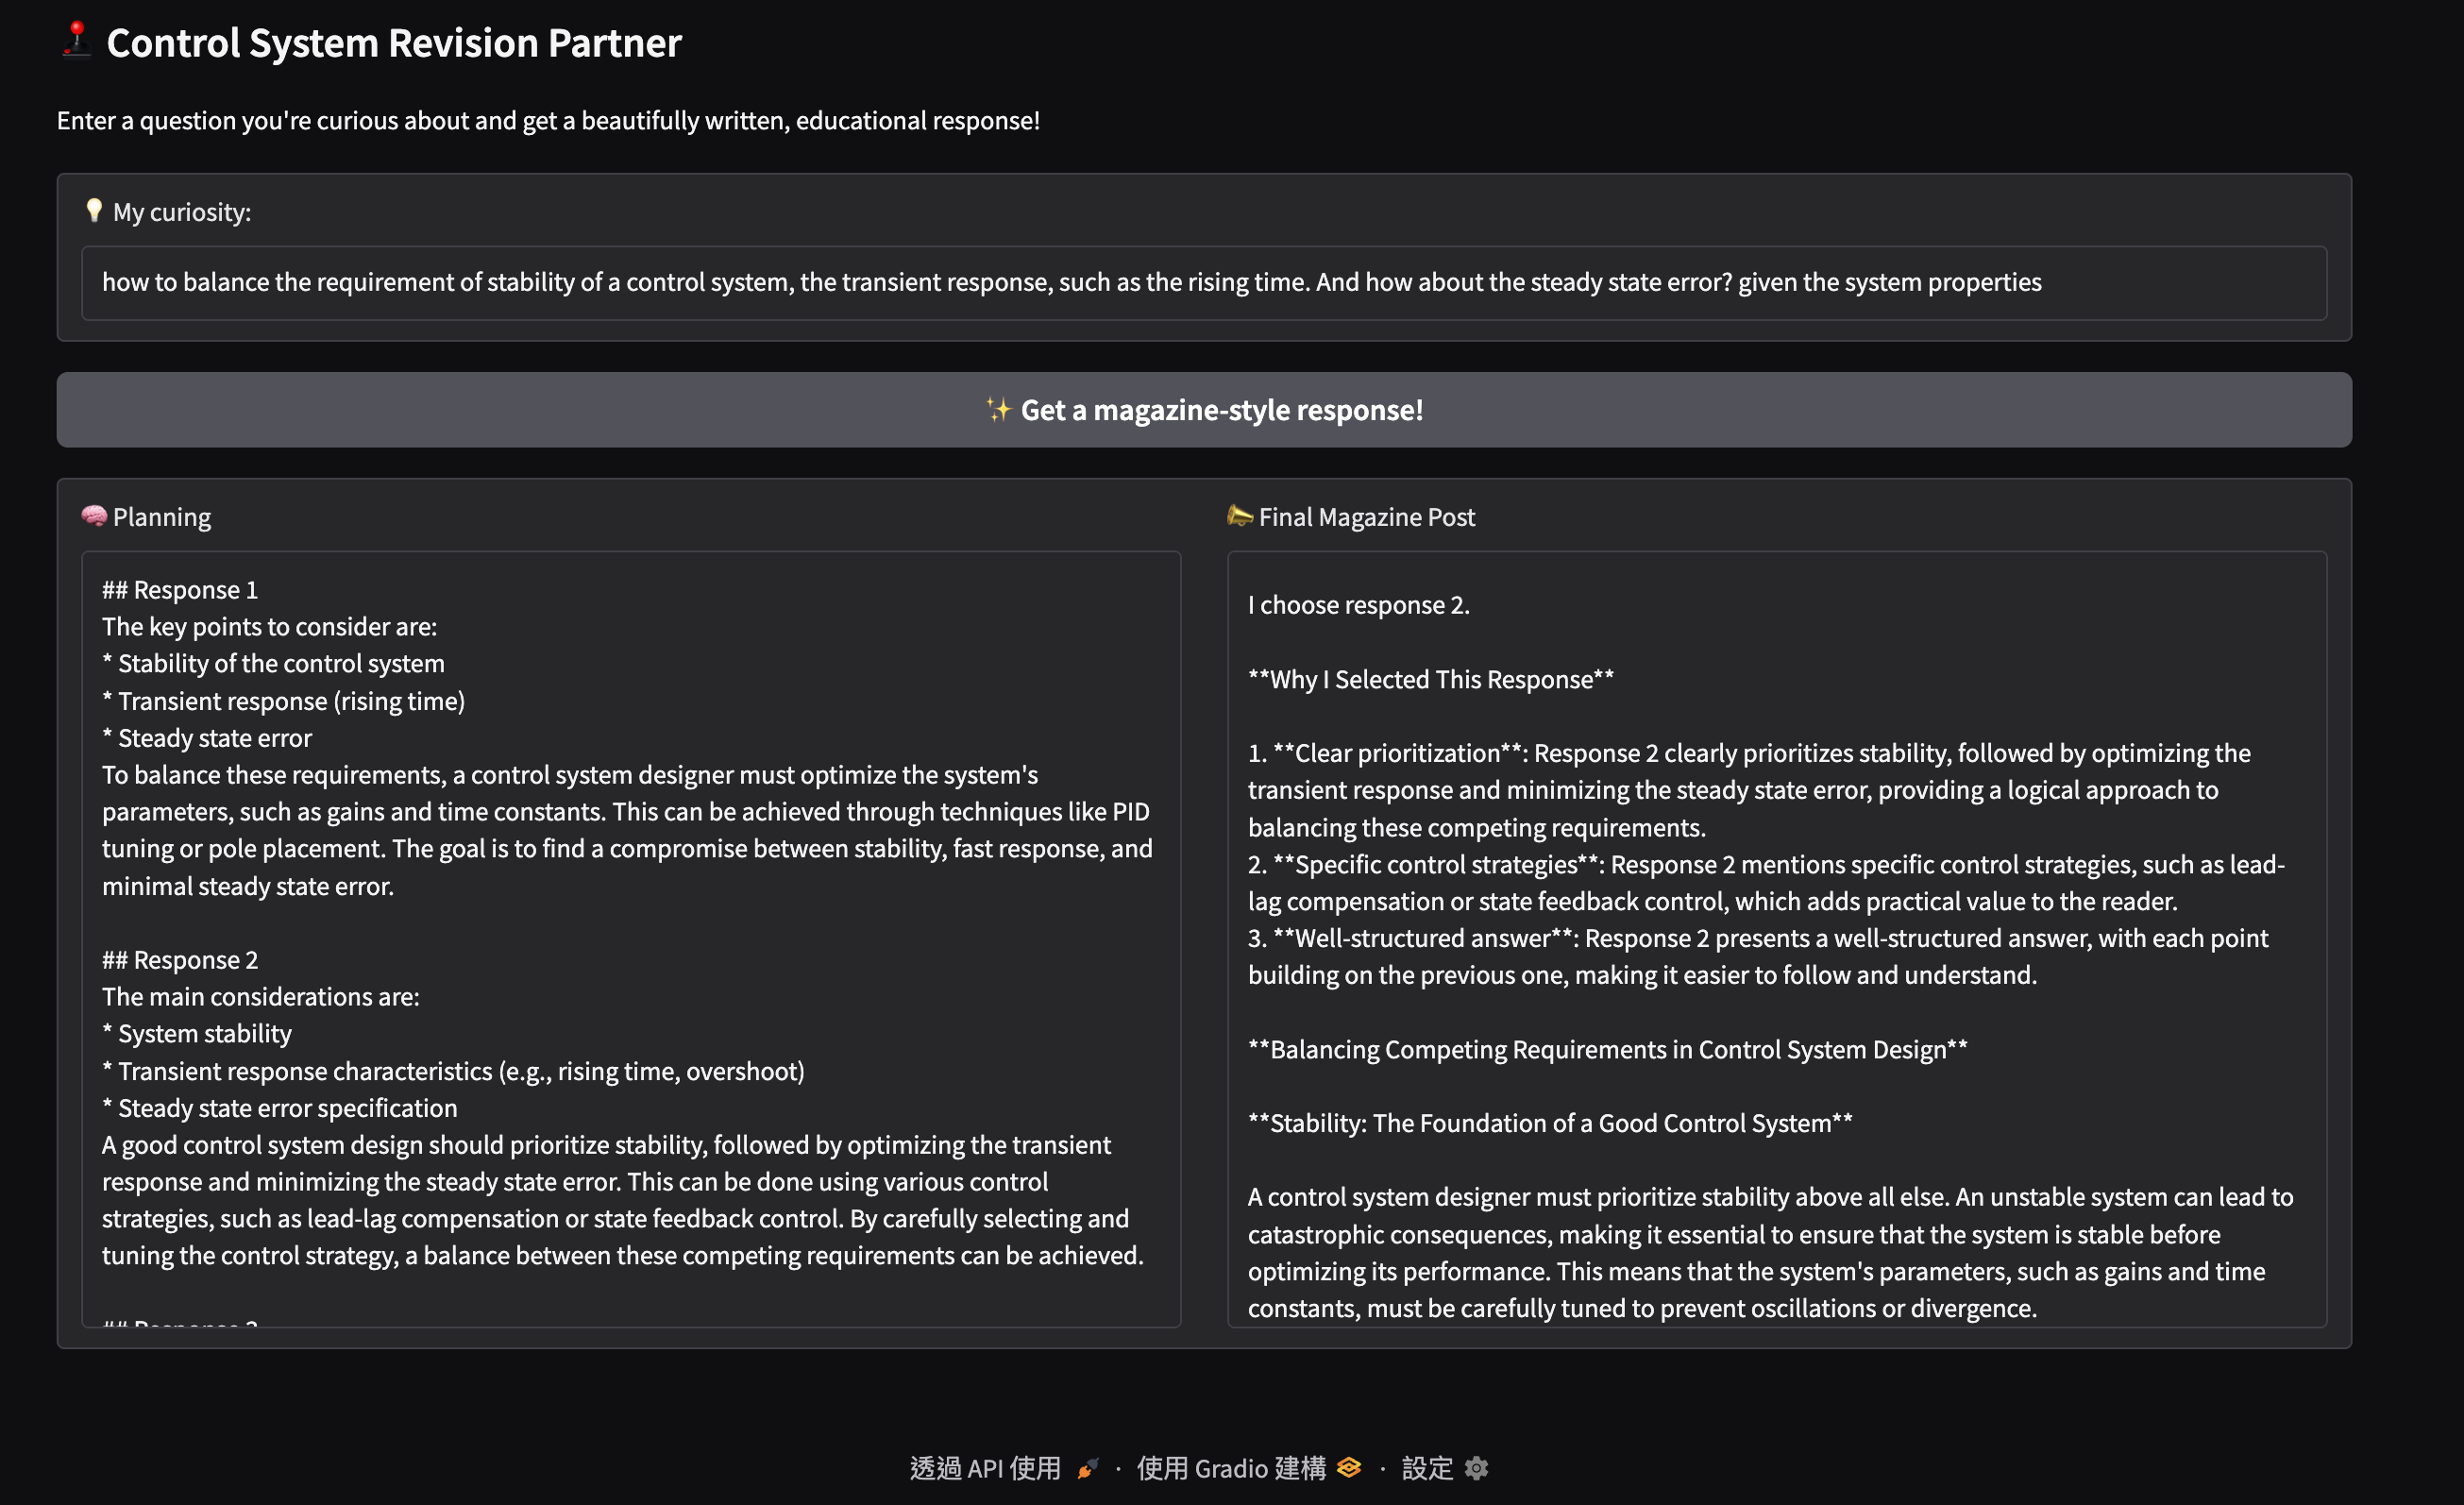

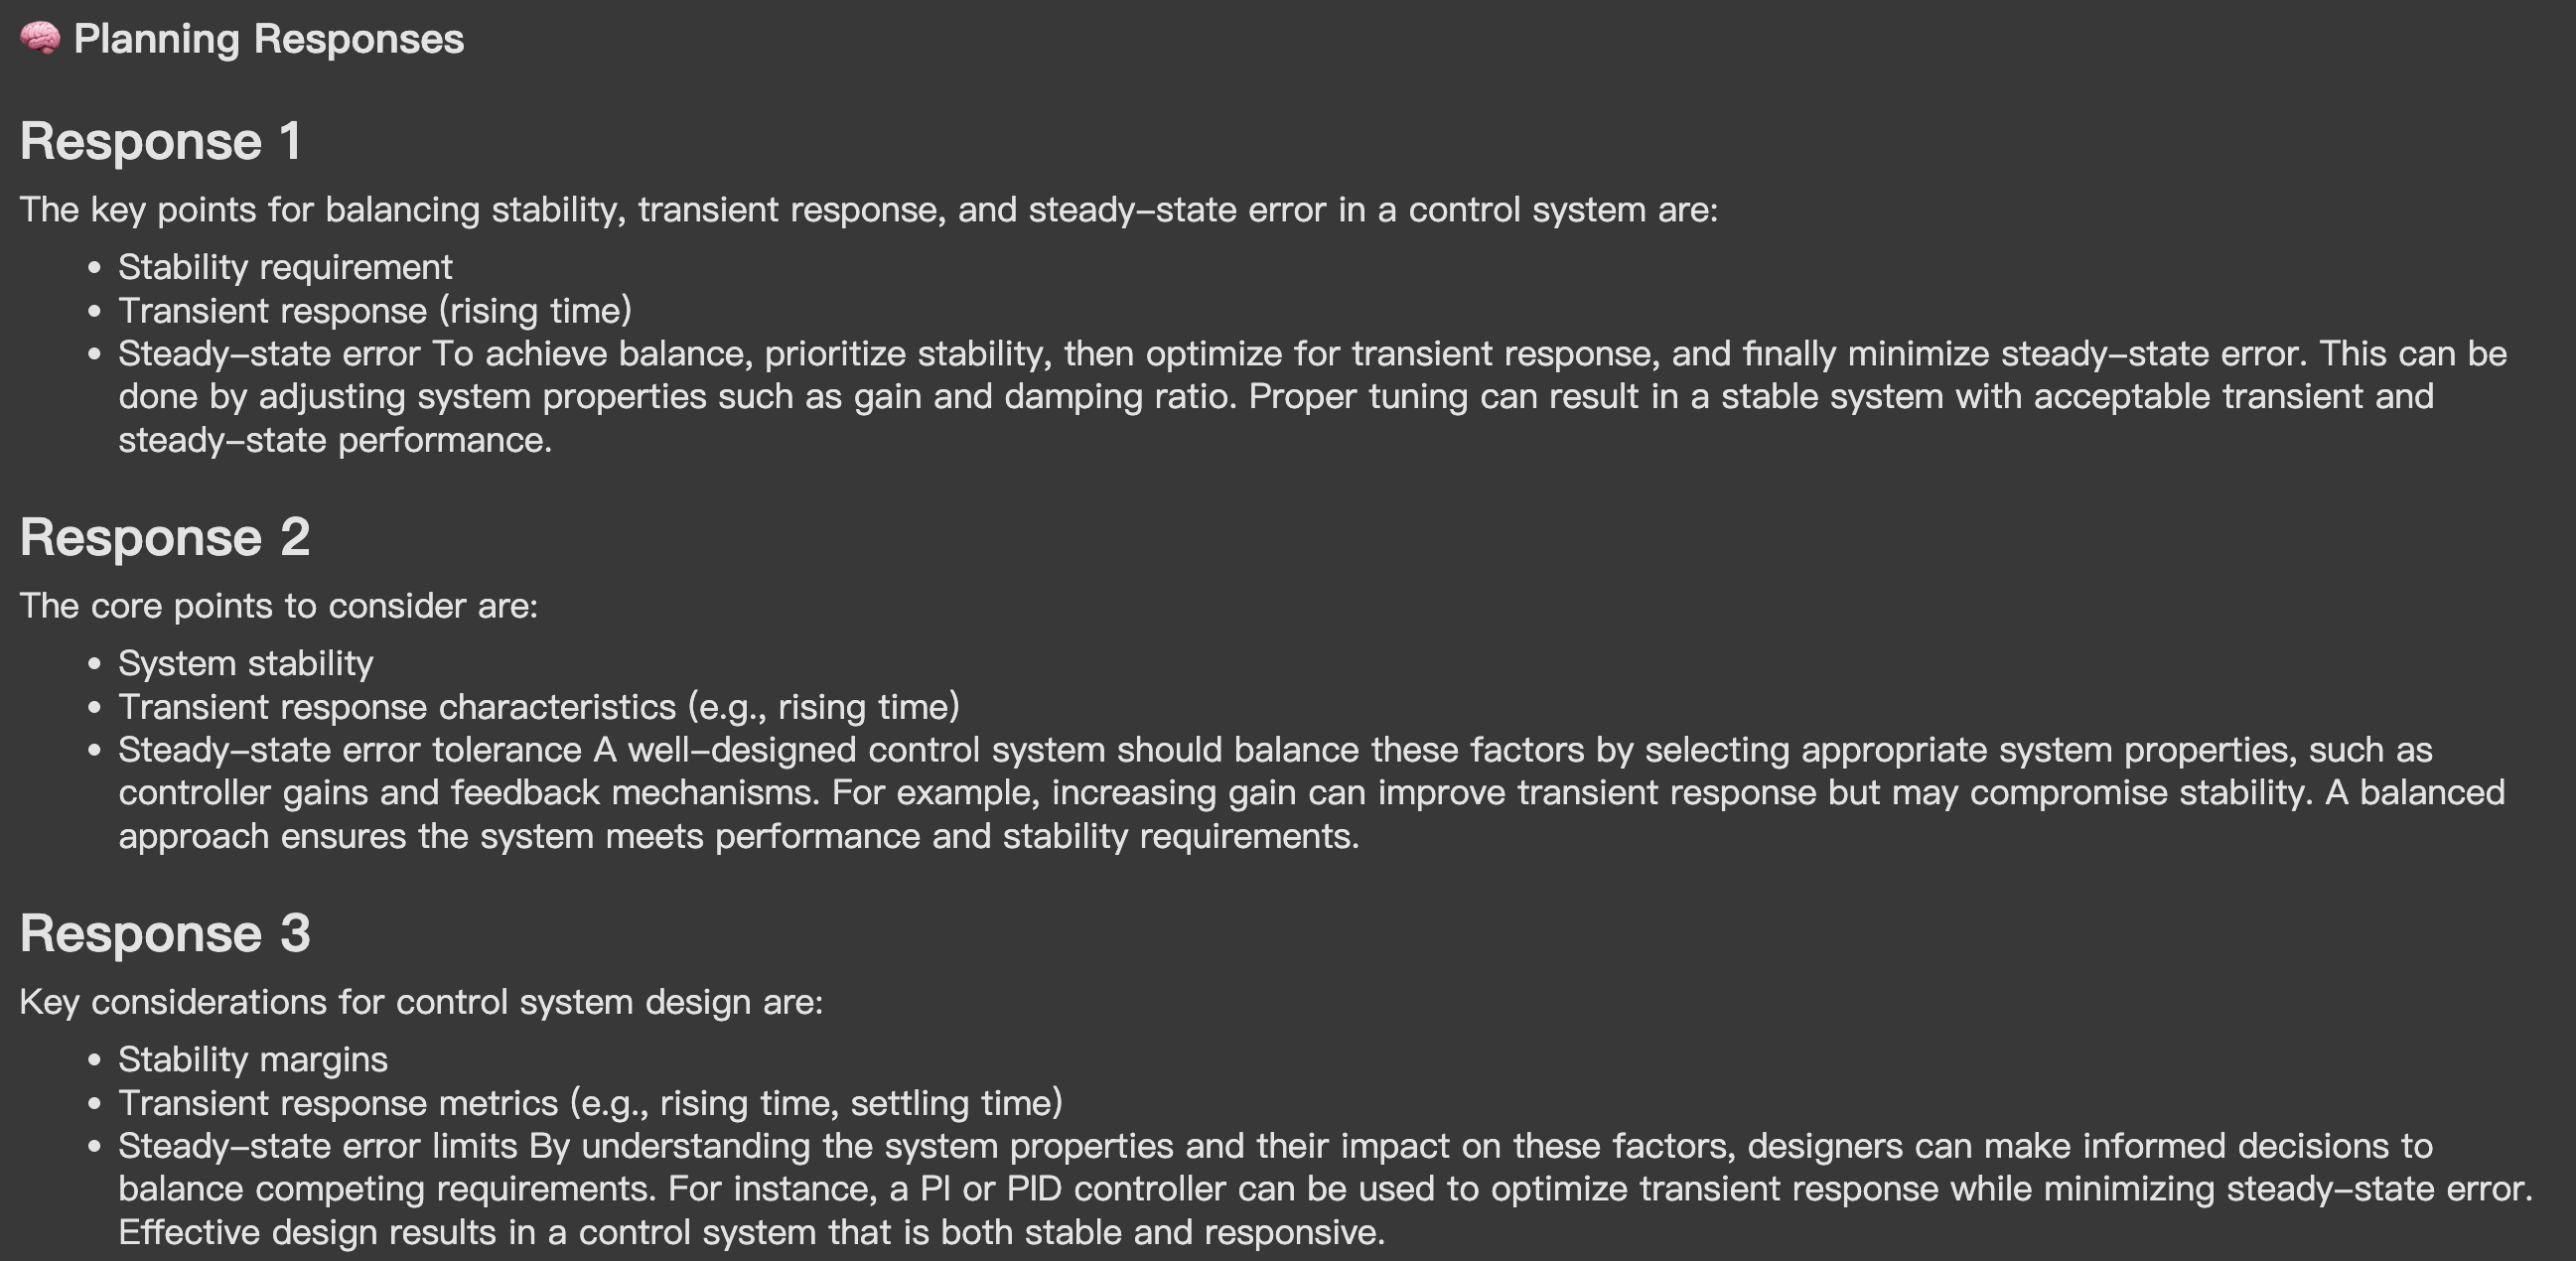

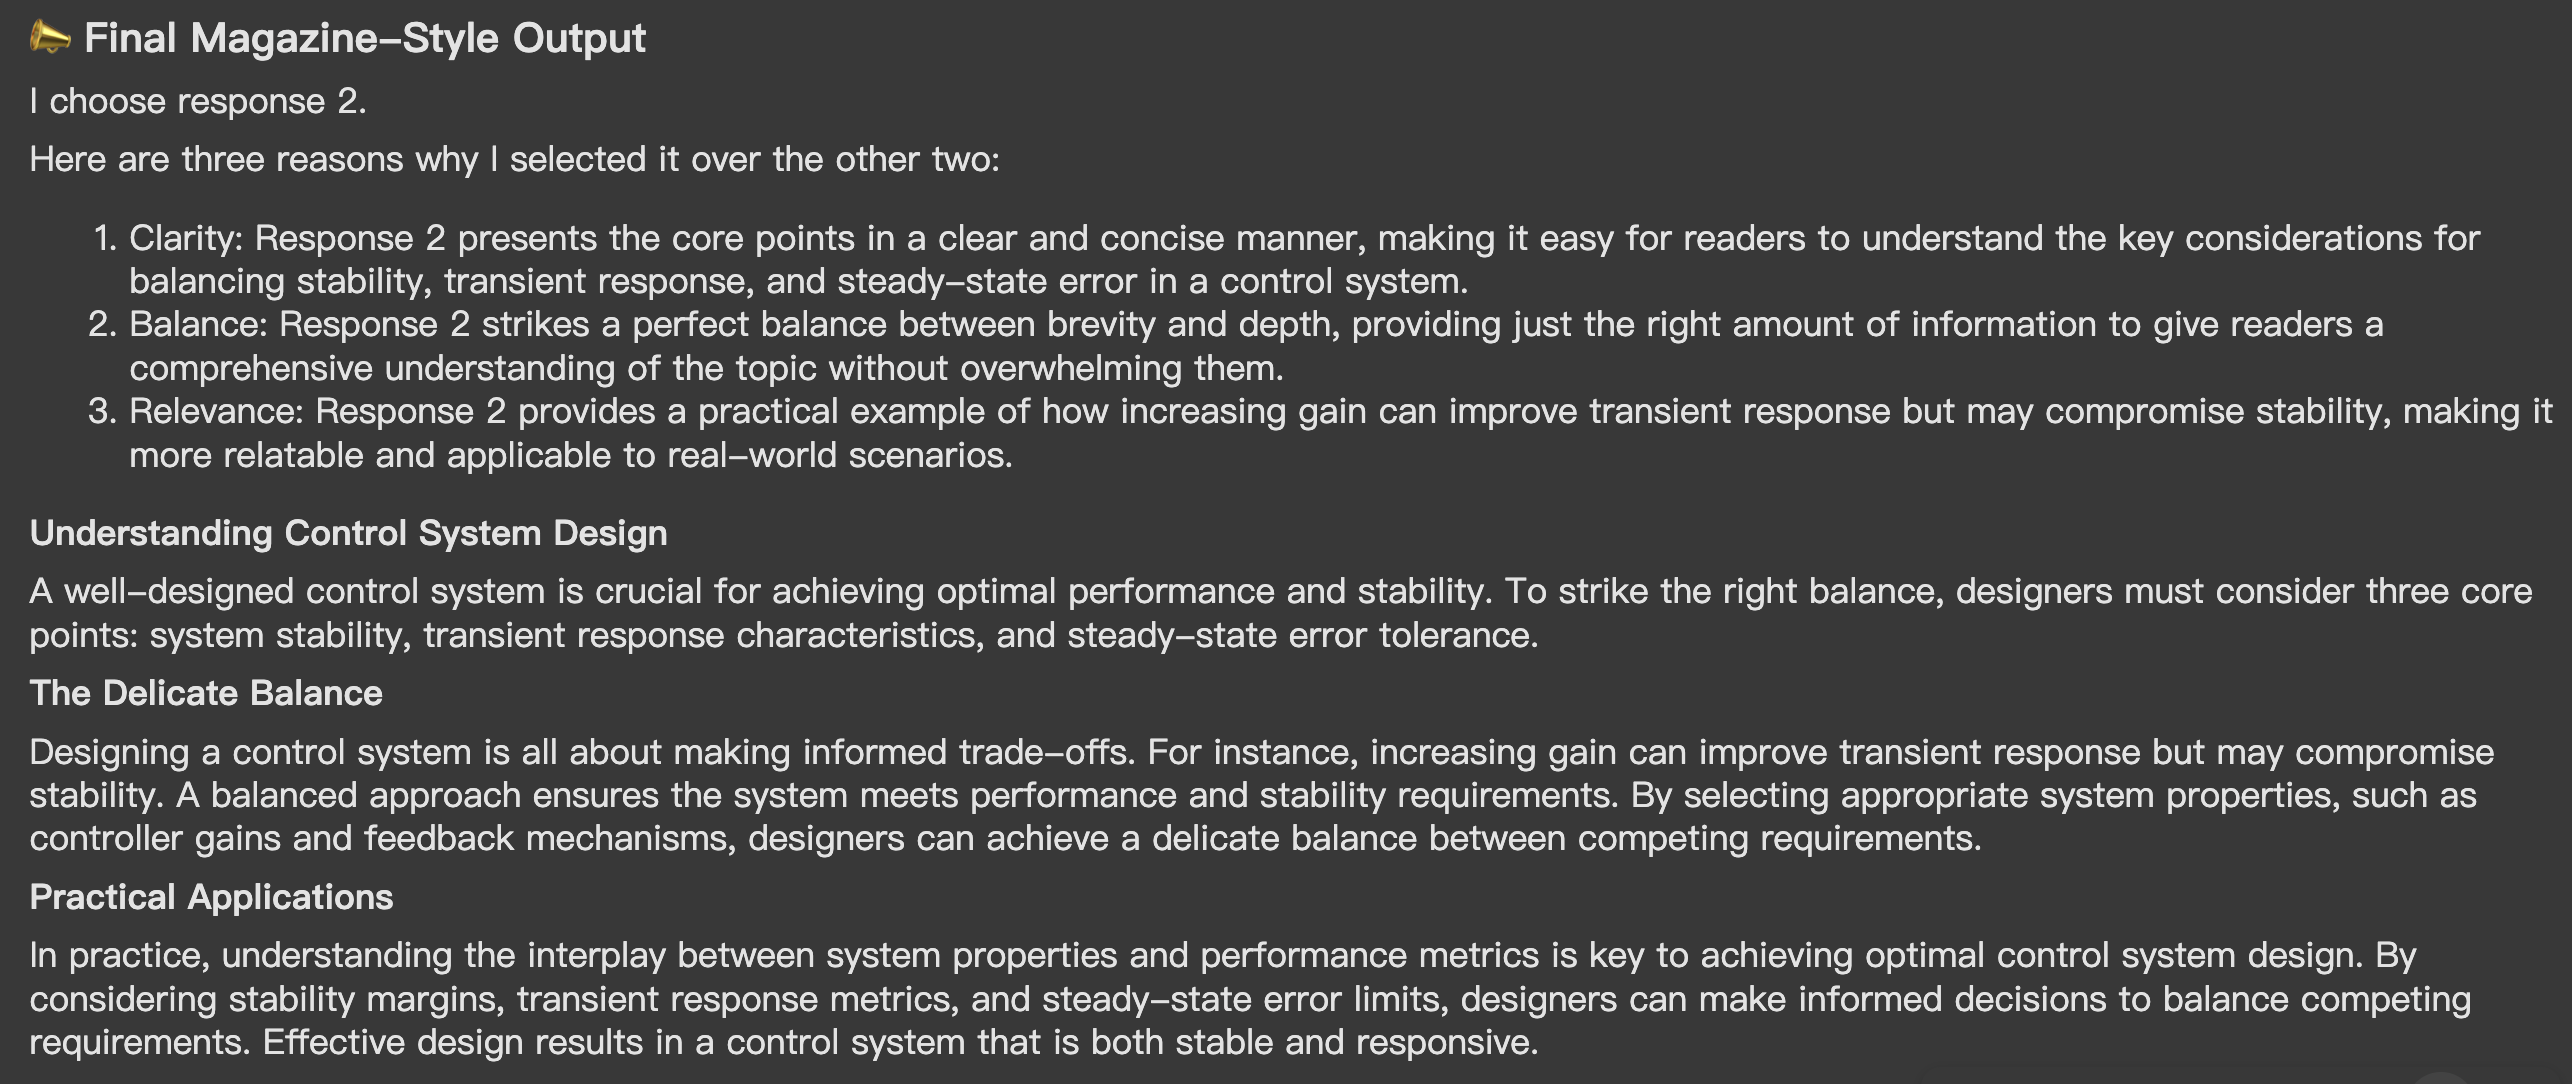